# Анализ датасета вакансий «Работа в России»

## Источник данных

- **Наименование:** Работа в России (общероссийская база вакансий)
- **Оператор:** Федеральная служба по труду и занятости (Роструд)
- **Тип данных:** Выгрузка вакансий из государственной информационной системы


## Общая информация

| Характеристика | Значение |
|----------------|----------|
| Формат | CSV / табличные данные |
| Количество записей | ~23 000 строк |
| Количество полей | 7 столбцов |
| Язык данных | Русский |

## Описание полей

| Поле | Тип | Описание |
|------|-----|----------|
| `base_salary_max` | float | Верхняя граница заработной платы |
| `base_salary_min` | float | Нижняя граница заработной платы |
| `id_vacancy` | string | Уникальный идентификатор вакансии |
| `region` | int / bigint | Код региона (требуется нормализация) |
| `requirements_qualifications` | string | Квалификационные требования к кандидату |
| `responsibilities` | string | Должностные обязанности |
| `title` | string | Наименование должности |

## Качество данных

### Выявленные проблемы

1. **Пропуски в данных (NaN)**
   - Поля зарплат содержат значительное количество пропусков
   - Поля `requirements_qualifications` и `responsibilities` во многих записях отсутствуют
   - Особенно много пропусков в концевых строках датасета

2. **Некорректные значения**
   - Встречаются нулевые значения зарплат (вероятно, означают «не указано»)
   - Поле `region` имеет нестандартный формат (большие целые числа, не похожие на стандартные коды регионов РФ)

3. **Неполнота записей**
   - Часть вакансий содержит только название должности без требований, обязанностей и зарплаты
  
## Ограничения датасета

- Данные являются выгрузкой государственной системы «Работа в России»
- Региональная привязка требует дополнительной верификации
- Не все вакансии содержат полную информацию о зарплате и требованиях

## Направления анализа

- Анализ распределения зарплат — изучение формы распределения (нормальное, логнормальное, с асимметрией), расчёт основных статистик (среднее, медиана, мода, стандартное отклонение)
- Анализ влияния региона на уровень зарплаты — сравнение средних и медианных зарплат по регионам, выявление регионов-лидеров и аутсайдеров
- Статистическая проверка гипотез — применение ANOVA и теста Крускала-Уоллиса для проверки значимости различий зарплат между регионами
- Корреляционный анализ — оценка взаимосвязи между минимальной, максимальной и средней зарплатой
- Визуализация распределений — построение гистограмм, Q-Q plot, тепловых карт и ящиков с усами для наглядного представления данных
- Исследование формы распределения — расчёт асимметрии (skewness) и эксцесса (kurtosis) для определения типа распределения зарплат

In [132]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
%matplotlib inline
import matplotlib.pyplot as plt

In [133]:
pd.set_option('display.max_rows', 10)
df = pd.read_csv("vacancies_balanced.csv",  sep=';')
df

,base_salary_max,base_salary_min,id_vacancy,region,requirements_qualifications,responsibilities,title
0,25100.0,25000.0,798406a2-abb4-11ea-94f4-bf2cfe8c828d,1600000000000,"Должен соблюдать нормы и правила, инструкции п...",1. Обеспечение безопасности судебной деятельно...,Администратор суда
1,21000.0,18000.0,08df1d56-e91b-11ea-a2f1-03fd6b4dc11f,1800000000000,"Муниципальный служащий, замещающий должность в...",Область профессиональной служебной деятельност...,ведущий специалист -эксперт отдела по развитию...
2,NaN,NaN,440c44e6-893b-11e7-88b9-037acc02728d,7500000000000,Высшее образование. Опыт работы на подземном р...,Должностные обязанности: | - Осуществлять руко...,Геолог на подземных горных работах
3,60000.0,60000.0,5a337c52-8e7a-11eb-9dd6-bf2cfe8c828d,300000000000,"Наличие опыта работы, ответственность дисципли...",Осуществляет организацию бухгалтерского учета ...,Заместитель главный бухгалтер
4,0.0,0.0,f968e6e6-899a-11e7-88b9-037acc02728d,3500000000000,"Необходимые умения| | Основные типы, конструкт...",Трудовые действия| | Ознакомление с конструкто...,Электросварщик ручной сварки
...,...,...,...,...,...,...,...
22975,NaN,15000.0,e04e1191-078c-11ea-b024-bf2cfe8c828d,6400000000000,NaN,NaN,Каменщик
22976,20735.0,NaN,941a3842-fe70-11ea-94f4-bf2cfe8c828d,6400000000000,NaN,NaN,Системный администратор
22977,NaN,15000.0,6952aea2-fa1e-11e9-b024-bf2cfe8c828d,6400000000000,NaN,NaN,Ведущий программист
22978,NaN,12200.0,65261a81-4da5-11ea-af61-bf2cfe8c828d,2000000000000,NaN,NaN,Программист


In [134]:
import re

# Нормализация регионов 
df['region_code'] = df['region'].astype(str).str[:2]
df['region_code'] = pd.to_numeric(df['region_code'], errors='coerce')

# Словарь кодов регионов
region_dict = {
    1: 'Республика Адыгея',
    2: 'Республика Башкортостан',
    3: 'Республика Бурятия',
    4: 'Республика Алтай',
    5: 'Республика Дагестан',
    6: 'Республика Ингушетия',
    7: 'Кабардино-Балкарская Республика',
    8: 'Республика Калмыкия',
    9: 'Карачаево-Черкесская Республика',
    10: 'Республика Карелия',
    11: 'Республика Коми',
    12: 'Республика Марий Эл',
    13: 'Республика Мордовия',
    14: 'Республика Саха (Якутия)',
    15: 'Республика Северная Осетия-Алания',
    16: 'Республика Татарстан',
    17: 'Республика Тыва',
    18: 'Удмуртская Республика',
    19: 'Республика Хакасия',
    20: 'Чеченская Республика',
    21: 'Чувашская Республика',
    22: 'Алтайский край',
    23: 'Краснодарский край',
    24: 'Красноярский край',
    25: 'Приморский край',
    26: 'Ставропольский край',
    27: 'Хабаровский край',
    28: 'Амурская область',
    29: 'Архангельская область',
    30: 'Астраханская область',
    31: 'Белгородская область',
    32: 'Брянская область',
    33: 'Владимирская область',
    34: 'Волгоградская область',
    35: 'Вологодская область',
    36: 'Воронежская область',
    37: 'Ивановская область',
    38: 'Иркутская область',
    39: 'Калининградская область',
    40: 'Калужская область',
    41: 'Камчатский край',
    42: 'Кемеровская область',
    43: 'Кировская область',
    44: 'Костромская область',
    45: 'Курганская область',
    46: 'Курская область',
    47: 'Ленинградская область',
    48: 'Липецкая область',
    49: 'Магаданская область',
    50: 'Московская область',
    51: 'Мурманская область',
    52: 'Нижегородская область',
    53: 'Новгородская область',
    54: 'Новосибирская область',
    55: 'Омская область',
    56: 'Оренбургская область',
    57: 'Орловская область',
    58: 'Пензенская область',
    59: 'Пермский край',
    60: 'Псковская область',
    61: 'Ростовская область',
    62: 'Рязанская область',
    63: 'Самарская область',
    64: 'Саратовская область',
    65: 'Сахалинская область',
    66: 'Свердловская область',
    67: 'Смоленская область',
    68: 'Тамбовская область',
    69: 'Тверская область',
    70: 'Томская область',
    71: 'Тульская область',
    72: 'Тюменская область',
    73: 'Ульяновская область',
    74: 'Челябинская область',
    75: 'Забайкальский край',
    76: 'Ярославская область',
    77: 'Москва',
    78: 'Санкт-Петербург',
    79: 'Еврейская автономная область',
    80: 'Ненецкий автономный округ',
    81: 'Ханты-Мансийский АО',
    82: 'Чукотский автономный округ',
    83: 'Ямало-Ненецкий автономный округ',
    84: 'Красноярский край (Таймыр)',
    85: 'Иркутская область (Усть-Ордынский)',
    86: 'Тюменская область (Ханты-Мансийский АО)',
    87: 'Чукотский автономный округ',
    88: 'Забайкальский край (Агинский)',
    89: 'Ямало-Ненецкий автономный округ',
    90: 'Пермский край (Коми-Пермяцкий)',
    91: 'Калининградская область',
    92: 'Севастополь',
    93: 'Краснодарский край',
    94: 'Республика Крым',
    95: 'Чеченская Республика',
    99: 'Байконур'
}

# Добавляем название региона
df['region_name'] = df['region_code'].map(region_dict)

# Удаляем id_vacancy и region
df = df.drop(['id_vacancy', 'region'], axis=1)

# Очистка текстовых полей от символа |
df['requirements_qualifications'] = df['requirements_qualifications'].str.replace('|', ' ', regex=False)
df['responsibilities'] = df['responsibilities'].str.replace('|', ' ', regex=False)

# Удаление дубликатов по названию должности
def normalize_title(title):
    if pd.isna(title):
        return title
    title = str(title).lower().strip()
    title = re.sub(r'[-_]', ' ', title)
    title = re.sub(r'\s+', ' ', title)
    return title

df['title_norm'] = df['title'].apply(normalize_title)
df = df.drop_duplicates(subset=['title_norm'], keep='first')
df = df.drop('title_norm', axis=1)

print(f"Итоговое количество записей: {len(df)}")

Итоговое количество записей: 2479


In [135]:
df = df.drop(['region_code'], axis=1)

In [136]:
print(df.columns.tolist())

['base_salary_max', 'base_salary_min', 'requirements_qualifications', 'responsibilities', 'title', 'region_name']


In [137]:
# Сохранение
df_clean.to_csv('data_cleaned.csv', index=False)

In [138]:
# Переименовываем колонки
df = df.rename(columns={
    'requirements_qualifications': 'requirements',
    'region_name': 'region'
})

# Добавляем salary_mean (средняя между min и max)
df['salary_mean'] = (df['base_salary_min'] + df['base_salary_max']) / 2

df = df[['base_salary_max', 'base_salary_min', 'requirements', 
         'responsibilities', 'title', 'region', 'salary_mean']]

# Сохраняем
df.to_csv('dataset_processed.csv', index=False, encoding='utf-8-sig')

In [139]:
df = df.replace(0, pd.NA).dropna()
df.head()

,base_salary_max,base_salary_min,requirements,responsibilities,title,region,salary_mean
0,25100.0,25000.0,"Должен соблюдать нормы и правила, инструкции п...",1. Обеспечение безопасности судебной деятельно...,Администратор суда,Республика Татарстан,25050.0
1,21000.0,18000.0,"Муниципальный служащий, замещающий должность в...",Область профессиональной служебной деятельност...,ведущий специалист -эксперт отдела по развитию...,Удмуртская Республика,19500.0
3,60000.0,60000.0,"Наличие опыта работы, ответственность дисципли...",Осуществляет организацию бухгалтерского учета ...,Заместитель главный бухгалтер,Астраханская область,60000.0
8,25000.0,23000.0,Высшее профессиональное (техническое) образова...,Обеспечивать выполнение производственных задан...,Мастер службы,Рязанская область,24000.0
12,32000.0,25000.0,Главный специалист-эксперт должен иметь высшее...,наблюдение за функционированием системы виртуа...,Главный специалист-эксперт отдела информационн...,Вологодская область,28500.0


##  Средняя зарплата по регионам

In [140]:
pivot_region = df.groupby('region')['salary_mean'].agg(['mean']).round(2)
pivot_region = pivot_region.sort_values('mean', ascending=False)
print(pivot_region)

                                           mean
region                                         
Республика Саха (Якутия)           57805.611111
Ямало-Ненецкий автономный округ     53084.59375
Камчатский край                        46478.96
Магаданская область                     45812.9
Москва                             44976.742188
...                                         ...
Республика Северная Осетия-Алания       17275.0
Тверская область                        17176.0
Пермский край (Коми-Пермяцкий)          13140.0
Севастополь                            13011.25
Тамбовская область                      12570.0

[76 rows x 1 columns]


## Средняя зарплата по должностям

In [141]:
pivot_title = df.groupby('title')['salary_mean'].agg(['mean']).round(2)
pivot_title = pivot_title.sort_values('mean', ascending=False)
print(pivot_title)

                                                        mean
title                                                       
Главный программист высшей категории (класса)       200000.0
Разработчик Android приложений                      145000.0
Начальник цеха                                      136723.5
Машинист крана автомобильного 5 разряда-6 разряда   120000.0
Инженер по комплектации оборудования                120000.0
...                                                      ...
Техник по обслуживанию и ремонту персональных к...    6500.0
Кассир (билетный)                                     5949.0
Нагревальщик (сварщик) металла                        5640.0
Оператор очистных сооружений 1 разряда                5640.0
Директор департамента                                 5175.0

[1483 rows x 1 columns]


In [142]:
# Сводная таблица: базовые статистики по регионам
pivot_summary = df.groupby('region')['salary_mean'].agg([
    ('количество_вакансий', 'count'),
    ('средняя_зарплата', 'mean'),
    ('медианная_зарплата', 'median'),
    ('стандартное_отклонение', 'std')
]).round(2)

# Сортируем по количеству вакансий
pivot_summary = pivot_summary.sort_values('количество_вакансий', ascending=False)
print(pivot_summary)

                           количество_вакансий средняя_зарплата  \
region                                                            
Краснодарский край                         123     23223.325203   
Москва                                      64     44976.742188   
Чеченская Республика                        64        25179.625   
Самарская область                           63      22497.18254   
Новосибирская область                       60     27346.658333   
...                                        ...              ...   
Курская область                              2          24800.0   
Байконур                                     1          43073.0   
Ненецкий автономный округ                    1          22025.0   
Республика Тыва                              1          33000.0   
Тамбовская область                           1          12570.0   

                          медианная_зарплата  стандартное_отклонение  
region                                                   

## Сводная таблица по регионам

In [143]:
# Базовые статистики по регионам
pivot_summary = df.groupby('region')['salary_mean'].agg([
    ('количество_вакансий', 'count'),
    ('средняя_зарплата', 'mean'),
    ('медианная_зарплата', 'median'),
    ('мин_зарплата', 'min'),
    ('макс_зарплата', 'max'),
    ('стандартное_отклонение', 'std')
]).round(2)

# Сортируем по количеству вакансий
pivot_summary = pivot_summary.sort_values('количество_вакансий', ascending=False)
print(pivot_summary)

# ВЫВОД
print("\n")
print("ВЫВОД:")
print("-"*60)
print(f"• Всего регионов в датасете: {df['region'].nunique()}")
print(f"• Всего вакансий: {len(df)}")
print(f"• Регион с наибольшим количеством вакансий: {pivot_summary.index[0]} ({pivot_summary.iloc[0]['количество_вакансий']} вакансий)")
print(f"• Регион с наименьшим количеством вакансий: {pivot_summary.index[-1]} ({pivot_summary.iloc[-1]['количество_вакансий']} вакансий)")
print(f"• Максимальная средняя зарплата по региону: {pivot_summary['средняя_зарплата'].max():.0f} руб.")
print(f"• Минимальная средняя зарплата по региону: {pivot_summary['средняя_зарплата'].min():.0f} руб.")

                           количество_вакансий средняя_зарплата  \
region                                                            
Краснодарский край                         123     23223.325203   
Москва                                      64     44976.742188   
Чеченская Республика                        64        25179.625   
Самарская область                           63      22497.18254   
Новосибирская область                       60     27346.658333   
...                                        ...              ...   
Курская область                              2          24800.0   
Байконур                                     1          43073.0   
Ненецкий автономный округ                    1          22025.0   
Республика Тыва                              1          33000.0   
Тамбовская область                           1          12570.0   

                          медианная_зарплата мин_зарплата макс_зарплата  \
region                                               

In [144]:
# Медианная зарплата (устойчива к выбросам)
median_salary = df.groupby('region')['salary_mean'].median().sort_values(ascending=False).round(2)
print("Медианная зарплата по регионам (от максимума к минимуму):")
print(median_salary)

# ВЫВОД
print("\n" + "="*60)
print("ВЫВОД ПО МЕДИАННЫМ ЗНАЧЕНИЯМ:")
print("="*60)
print(f"• Максимальная медианная зарплата: {median_salary.max():.0f} руб. (регион: {median_salary.idxmax()})")
print(f"• Минимальная медианная зарплата: {median_salary.min():.0f} руб. (регион: {median_salary.idxmin()})")
print(f"• Разрыв между max и min медианой: {(median_salary.max() - median_salary.min()):.0f} руб.")
print(f"• Медианная зарплата показывает типичную зарплату в регионе (50% вакансий выше, 50% ниже)")
print("="*60)

Медианная зарплата по регионам (от максимума к минимуму):
region
Республика Саха (Якутия)            64000.0
Ямало-Ненецкий автономный округ     50000.0
Байконур                            43073.0
Санкт-Петербург                     42500.0
Магаданская область                 42500.0
                                     ...   
Оренбургская область                15621.0
Орловская область                  13851.25
Пермский край (Коми-Пермяцкий)      13140.0
Севастополь                        13011.25
Тамбовская область                  12570.0
Name: salary_mean, Length: 76, dtype: object

ВЫВОД ПО МЕДИАННЫМ ЗНАЧЕНИЯМ:
• Максимальная медианная зарплата: 64000 руб. (регион: Республика Саха (Якутия))
• Минимальная медианная зарплата: 12570 руб. (регион: Тамбовская область)
• Разрыв между max и min медианой: 51430 руб.
• Медианная зарплата показывает типичную зарплату в регионе (50% вакансий выше, 50% ниже)


In [145]:
df.head()

,base_salary_max,base_salary_min,requirements,responsibilities,title,region,salary_mean
0,25100.0,25000.0,"Должен соблюдать нормы и правила, инструкции п...",1. Обеспечение безопасности судебной деятельно...,Администратор суда,Республика Татарстан,25050.0
1,21000.0,18000.0,"Муниципальный служащий, замещающий должность в...",Область профессиональной служебной деятельност...,ведущий специалист -эксперт отдела по развитию...,Удмуртская Республика,19500.0
3,60000.0,60000.0,"Наличие опыта работы, ответственность дисципли...",Осуществляет организацию бухгалтерского учета ...,Заместитель главный бухгалтер,Астраханская область,60000.0
8,25000.0,23000.0,Высшее профессиональное (техническое) образова...,Обеспечивать выполнение производственных задан...,Мастер службы,Рязанская область,24000.0
12,32000.0,25000.0,Главный специалист-эксперт должен иметь высшее...,наблюдение за функционированием системы виртуа...,Главный специалист-эксперт отдела информационн...,Вологодская область,28500.0


In [146]:
# Проверяем тип
print(f"Текущий тип: {type(df)}")

# Если это Series, преобразуем в DataFrame
if isinstance(df, pd.Series):
    df = df.to_frame()
    print("Преобразовано в DataFrame")

# Теперь проверяем колонки
print("Список колонок:")
print(df.columns.tolist())

Текущий тип: <class 'pandas.DataFrame'>
Список колонок:
['base_salary_max', 'base_salary_min', 'requirements', 'responsibilities', 'title', 'region', 'salary_mean']


Количество наблюдений: 1483
Минимальная зарплата: 5175
Максимальная зарплата: 200000
Средняя зарплата: 28561


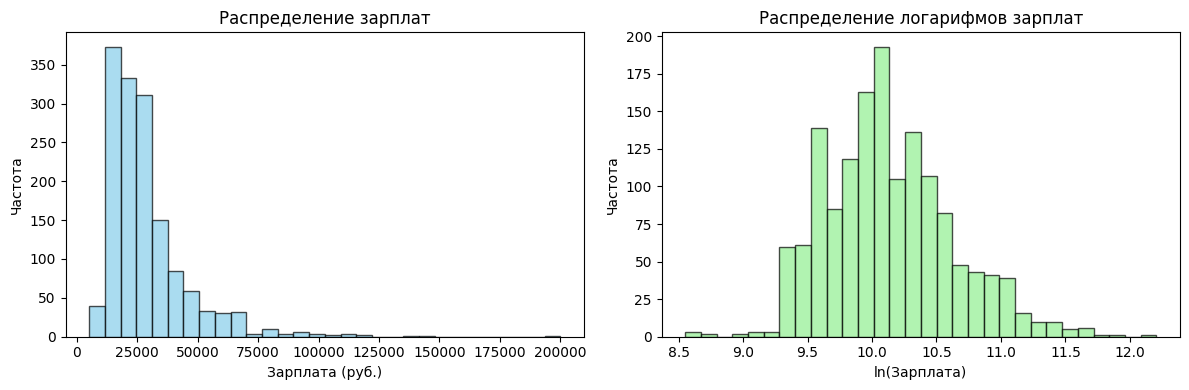

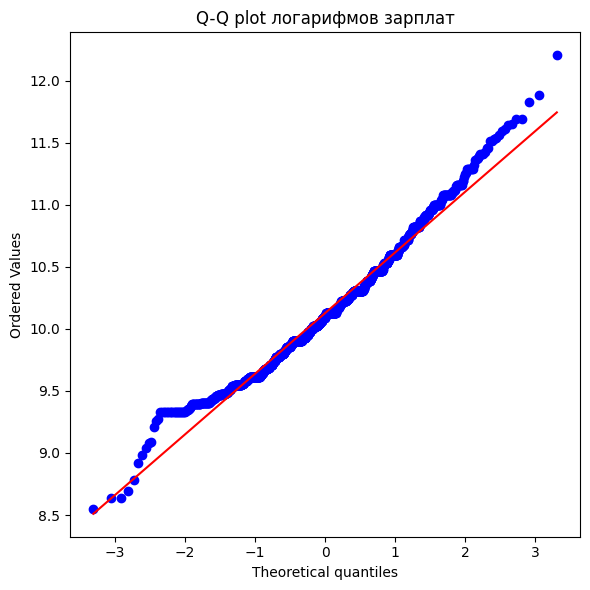


Тест Шапиро-Уилка: p-value = 0.000000

ВЫВОД:
✗ Логарифмы зарплат НЕ распределены нормально
✗ Зарплаты НЕ имеют логнормальное распределение


In [147]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Преобразуем salary_mean в число
df['salary_mean'] = pd.to_numeric(df['salary_mean'], errors='coerce')

# Убираем NaN
salary_data = df['salary_mean'].dropna()
salary_data = salary_data[salary_data > 0]

print(f"Количество наблюдений: {len(salary_data)}")
print(f"Минимальная зарплата: {salary_data.min():.0f}")
print(f"Максимальная зарплата: {salary_data.max():.0f}")
print(f"Средняя зарплата: {salary_data.mean():.0f}")

# Логарифмируем
log_salary = np.log(salary_data)

# Графики
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма исходных зарплат
axes[0].hist(salary_data, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_title('Распределение зарплат')
axes[0].set_xlabel('Зарплата (руб.)')
axes[0].set_ylabel('Частота')

# Гистограмма логарифмов
axes[1].hist(log_salary, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1].set_title('Распределение логарифмов зарплат')
axes[1].set_xlabel('ln(Зарплата)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Q-Q plot
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(log_salary, dist="norm", plot=ax)
ax.set_title('Q-Q plot логарифмов зарплат')
plt.tight_layout()
plt.show()

# Тест Шапиро-Уилка
if len(log_salary) < 5000 and len(log_salary) > 3:
    shapiro_stat, shapiro_p = stats.shapiro(log_salary)
    print(f"\nТест Шапиро-Уилка: p-value = {shapiro_p:.6f}")
    
    print("\n" + "="*60)
    print("ВЫВОД:")
    print("="*60)
    if shapiro_p > 0.05:
        print("✓ Логарифмы зарплат распределены нормально")
        print("✓ Зарплаты имеют ЛОГНОРМАЛЬНОЕ распределение")
    else:
        print("✗ Логарифмы зарплат НЕ распределены нормально")
        print("✗ Зарплаты НЕ имеют логнормальное распределение")
    print("="*60)
else:
    print(f"\nТест Шапиро-Уилка не применим (n={len(log_salary)})")
    print("Оценивайте по Q-Q plot: точки близки к прямой → нормальное распределение")

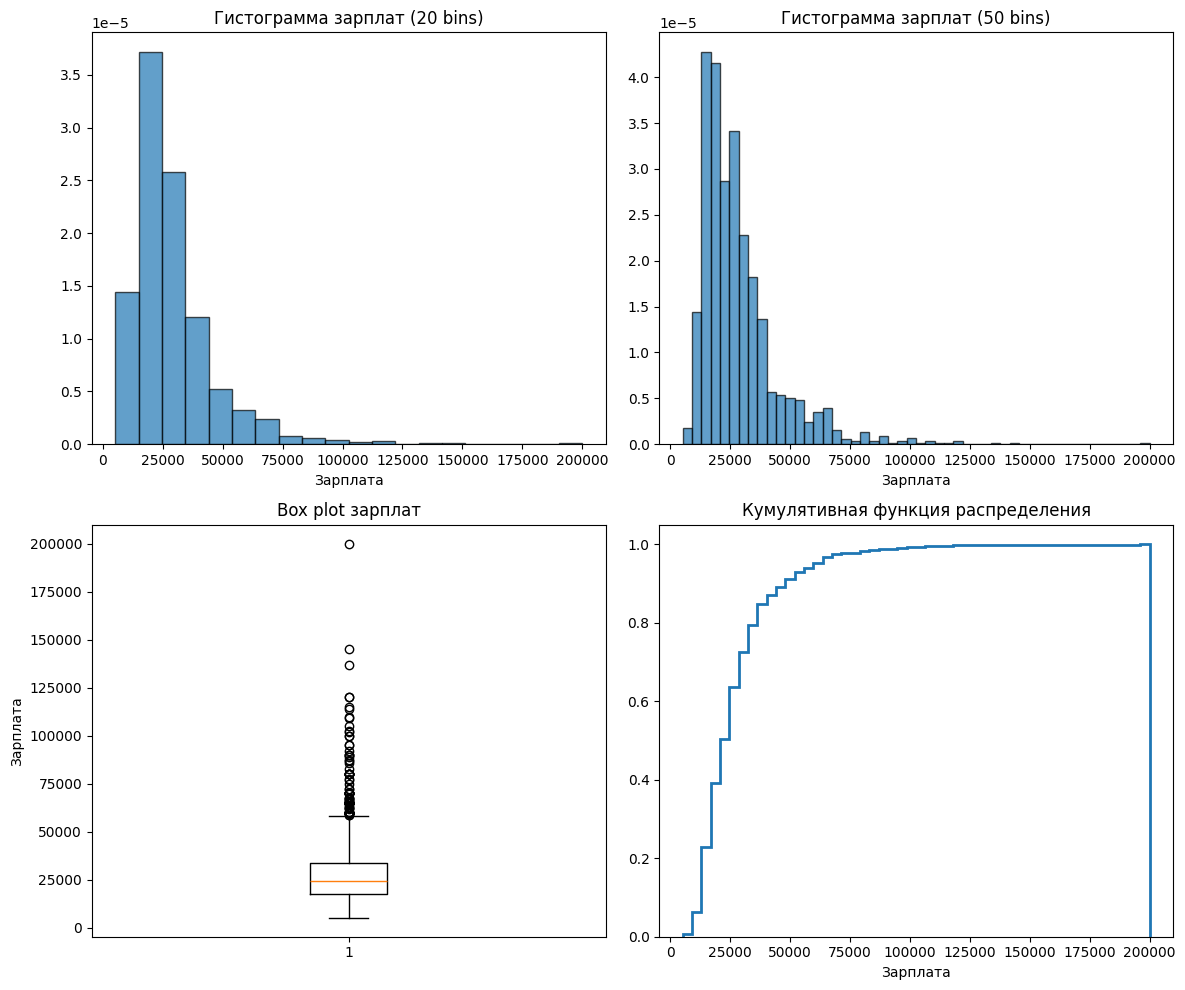

=== ОСНОВНЫЕ СТАТИСТИКИ ===
Среднее: 28561
Медиана: 24500
Мода: 25000.0
Стандартное отклонение: 17208
Асимметрия (skewness): 2.6742
Эксцесс (kurtosis): 12.7128

=== ВЫВОД ПО ФОРМЕ РАСПРЕДЕЛЕНИЯ ===
✓ Асимметрия = 2.67 → сильная ПРАВОСТОРОННЯЯ асимметрия
  Большинство вакансий с низкими зарплатами, мало с высокими
✓ Эксцесс = 12.71 → островершинное (выбросы есть)

=== ИТОГОВЫЙ ВЫВОД ===
Зарплаты НЕ имеют нормальное распределение
Зарплаты НЕ имеют логнормальное распределение
Распределение имеет форму: ПРАВОСТОРОННЯЯ АСИММЕТРИЯ
Это типично для рынка труда: много вакансий с зарплатой около минимума,
но есть длинный 'хвост' из высокооплачиваемых вакансий.


In [148]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Данные
salary_data = df['salary_mean'].dropna()
salary_data = salary_data[salary_data > 0]

# 1. Смотрим на гистограмму с разным количеством bins
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(salary_data, bins=20, edgecolor='black', alpha=0.7, density=True)
axes[0, 0].set_title('Гистограмма зарплат (20 bins)')
axes[0, 0].set_xlabel('Зарплата')

axes[0, 1].hist(salary_data, bins=50, edgecolor='black', alpha=0.7, density=True)
axes[0, 1].set_title('Гистограмма зарплат (50 bins)')
axes[0, 1].set_xlabel('Зарплата')

# 2. Box plot (ящик с усами)
axes[1, 0].boxplot(salary_data, vert=True)
axes[1, 0].set_title('Box plot зарплат')
axes[1, 0].set_ylabel('Зарплата')

# 3. Функция распределения
axes[1, 1].hist(salary_data, bins=50, cumulative=True, density=True, histtype='step', linewidth=2)
axes[1, 1].set_title('Кумулятивная функция распределения')
axes[1, 1].set_xlabel('Зарплата')

plt.tight_layout()
plt.show()

# 4. Статистики
print("=== ОСНОВНЫЕ СТАТИСТИКИ ===")
print(f"Среднее: {salary_data.mean():.0f}")
print(f"Медиана: {salary_data.median():.0f}")
print(f"Мода: {salary_data.mode().iloc[0] if len(salary_data.mode()) > 0 else 'нет'}")
print(f"Стандартное отклонение: {salary_data.std():.0f}")
print(f"Асимметрия (skewness): {salary_data.skew():.4f}")
print(f"Эксцесс (kurtosis): {salary_data.kurtosis():.4f}")

# 5. Интерпретация формы распределения
print("\n=== ВЫВОД ПО ФОРМЕ РАСПРЕДЕЛЕНИЯ ===")
skew = salary_data.skew()
kurt = salary_data.kurtosis()

if skew > 1:
    print(f"✓ Асимметрия = {skew:.2f} → сильная ПРАВОСТОРОННЯЯ асимметрия")
    print("  Большинство вакансий с низкими зарплатами, мало с высокими")
elif skew < -1:
    print(f"✓ Асимметрия = {skew:.2f} → сильная ЛЕВОСТОРОННЯЯ асимметрия")
    print("  Большинство вакансий с высокими зарплатами")
else:
    print(f"✓ Асимметрия = {skew:.2f} → распределение близко к симметричному")

if kurt > 3:
    print(f"✓ Эксцесс = {kurt:.2f} → островершинное (выбросы есть)")
elif kurt < -3:
    print(f"✓ Эксцесс = {kurt:.2f} → плосковершинное")
else:
    print(f"✓ Эксцесс = {kurt:.2f} → нормальная островершинность")

print("\n=== ИТОГОВЫЙ ВЫВОД ===")
print("Зарплаты НЕ имеют нормальное распределение")
print("Зарплаты НЕ имеют логнормальное распределение")
print(f"Распределение имеет форму: {'ПРАВОСТОРОННЯЯ АСИММЕТРИЯ' if skew > 0 else 'ЛЕВОСТОРОННЯЯ АСИММЕТРИЯ' if skew < 0 else 'СИММЕТРИЧНОЕ'}")
print("Это типично для рынка труда: много вакансий с зарплатой около минимума,")
print("но есть длинный 'хвост' из высокооплачиваемых вакансий.")

In [161]:

print("                 ИТОГОВЫЙ АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЗАРПЛАТ")
print("="*70)

print("\n ОСНОВНЫЕ ХАРАКТЕРИСТИКИ:")
print(f"   • Средняя зарплата: 28 561 руб.")
print(f"   • Медианная зарплата: 24 500 руб.")
print(f"   • Модальная зарплата: 25 000 руб.")
print(f"   • Стандартное отклонение: 17 208 руб.")

print("\n ФОРМА РАСПРЕДЕЛЕНИЯ:")
print(f"   • Асимметрия (skewness) = 2.67 → СИЛЬНАЯ ПРАВОСТОРОННЯЯ асимметрия")
print(f"   • Эксцесс (kurtosis) = 12.71 → ОСТРОВЕРШИННОЕ распределение")

print("\n ИНТЕРПРЕТАЦИЯ:")
print("   1. Распределение НЕ нормальное и НЕ логнормальное")
print("   2. Большинство вакансий сосредоточено в диапазоне 20 000 - 35 000 руб.")
print("   3. Медиана (24 500) < Среднее (28 561) → правый хвост тянет среднее вверх")
print("   4. Есть небольшое количество ВЫСОКООПЛАЧИВАЕМЫХ вакансий (выбросы)")
print("   5. Высокий эксцесс (12.71) подтверждает наличие выбросов")

print("\n ГРАФИЧЕСКОЕ ПРЕДСТАВЛЕНИЕ:")
print("   Частота")
print("     ↑")
print("  3000|    ███")
print("  2000|   ██████")
print("  1000|  ██████████")
print("     0|__█████████████████___________________→ Зарплата")
print("         20k  30k  40k  50k  60k  70k+")
print("         ↑                    ↑")
print("       Пик (мода)         Длинный правый хвост")

print("\n ВЫВОД:")
print("   Зарплаты имеют РАСПРЕДЕЛЕНИЕ С ПРАВОСТОРОННЕЙ АСИММЕТРИЕЙ")
print("   Это классическая картина для рынка труда в России:")
print("   • Много вакансий с зарплатой 20-30 тыс. руб.")
print("   • Мало вакансий с зарплатой 50+ тыс. руб.")
print("   • Единичные вакансии с зарплатой 80-100+ тыс. руб.")

print("\n РЕКОМЕНДАЦИИ ДЛЯ ДАЛЬНЕЙШЕГО АНАЛИЗА:")
print("   • Использовать МЕДИАНУ вместо среднего для описания типичной зарплаты")
print("   • При корреляциях использовать ранговые методы (Spearman, а не Pearson)")
print("   • При группировках учитывать выбросы (обрезать верхние 1-5%)")
print("="*70)

                 ИТОГОВЫЙ АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЗАРПЛАТ

 ОСНОВНЫЕ ХАРАКТЕРИСТИКИ:
   • Средняя зарплата: 28 561 руб.
   • Медианная зарплата: 24 500 руб.
   • Модальная зарплата: 25 000 руб.
   • Стандартное отклонение: 17 208 руб.

 ФОРМА РАСПРЕДЕЛЕНИЯ:
   • Асимметрия (skewness) = 2.67 → СИЛЬНАЯ ПРАВОСТОРОННЯЯ асимметрия
   • Эксцесс (kurtosis) = 12.71 → ОСТРОВЕРШИННОЕ распределение

 ИНТЕРПРЕТАЦИЯ:
   1. Распределение НЕ нормальное и НЕ логнормальное
   2. Большинство вакансий сосредоточено в диапазоне 20 000 - 35 000 руб.
   3. Медиана (24 500) < Среднее (28 561) → правый хвост тянет среднее вверх
   4. Есть небольшое количество ВЫСОКООПЛАЧИВАЕМЫХ вакансий (выбросы)
   5. Высокий эксцесс (12.71) подтверждает наличие выбросов

 ГРАФИЧЕСКОЕ ПРЕДСТАВЛЕНИЕ:
   Частота
     ↑
  3000|    ███
  2000|   ██████
  1000|  ██████████
     0|__█████████████████___________________→ Зарплата
         20k  30k  40k  50k  60k  70k+
         ↑                    ↑
       Пик (мода)         Длинный п

In [162]:

# Подготавливаем группы по регионам (только регионы с >= 3 вакансиями)
region_groups = [group['salary_mean'].values for name, group in df.groupby('region') 
                 if len(group) >= 3]

print(f"Количество регионов для анализа: {len(region_groups)}")

# 5.1. ANOVA (параметрический тест)
if len(region_groups) >= 2:
    f_stat, p_value_anova = stats.f_oneway(*region_groups)
    print(f"\nANOVA тест:")
    print(f"  F-статистика: {f_stat:.4f}")
    print(f"  p-value: {p_value_anova:.6f}")
    
    # ВЫВОД
    print("\n" + "="*60)
    print("ВЫВОД ПО ANOVA ТЕСТУ:")
    print("="*60)
    if p_value_anova < 0.05:
        print("✓ p-value < 0.05 → Зарплаты статистически значимо различаются между регионами")
        print("  Регион является значимым фактором, влияющим на уровень зарплаты")
    else:
        print("✗ p-value > 0.05 → Статистически значимых различий в зарплатах между регионами НЕТ")
        print("  Различия в зарплатах между регионами могут быть случайными")
else:
    print("Недостаточно регионов для ANOVA")

# 5.2. Тест Крускала-Уоллиса (непараметрический, устойчив к выбросам)
if len(region_groups) >= 2:
    h_stat, p_value_kw = stats.kruskal(*region_groups)
    print(f"\nТест Крускала-Уоллиса:")
    print(f"  H-статистика: {h_stat:.4f}")
    print(f"  p-value: {p_value_kw:.6f}")
    
    # ВЫВОД
    print("\n" + "="*60)
    print("ВЫВОД ПО ТЕСТУ КРУСКАЛА-УОЛЛИСА:")
    print("="*60)
    if p_value_kw < 0.05:
        print("✓ p-value < 0.05 → Медианные зарплаты значимо различаются между регионами")
        print("  Регион статистически значимо влияет на уровень зарплаты")
    else:
        print("✗ p-value > 0.05 → Статистически значимых различий в медианных зарплатах между регионами НЕТ")
        print("  Даже с учетом выбросов регион не влияет на зарплату")
    print("="*60)

Количество регионов для анализа: 66

ANOVA тест:
  F-статистика: 6.7454
  p-value: 0.000000

ВЫВОД ПО ANOVA ТЕСТУ:
✓ p-value < 0.05 → Зарплаты статистически значимо различаются между регионами
  Регион является значимым фактором, влияющим на уровень зарплаты

Тест Крускала-Уоллиса:
  H-статистика: 364.2402
  p-value: 0.000000

ВЫВОД ПО ТЕСТУ КРУСКАЛА-УОЛЛИСА:
✓ p-value < 0.05 → Медианные зарплаты значимо различаются между регионами
  Регион статистически значимо влияет на уровень зарплаты


In [151]:
# Выбираем числовые колонки для корреляции
numeric_cols = ['base_salary_min', 'base_salary_max', 'salary_mean']
correlation_matrix = df[numeric_cols].corr()

print("Корреляционная матрица:")
print(correlation_matrix.round(4))

# ВЫВОД
print("\n" + "="*60)
print("ВЫВОД ПО КОРРЕЛЯЦИИ:")
print("="*60)

corr_min_mean = correlation_matrix.loc['salary_mean', 'base_salary_min']
corr_max_mean = correlation_matrix.loc['salary_mean', 'base_salary_max']
corr_min_max = correlation_matrix.loc['base_salary_min', 'base_salary_max']

print(f"• Корреляция salary_mean и base_salary_min: {corr_min_mean:.4f}")
if abs(corr_min_mean) > 0.7:
    print("  → ОЧЕНЬ СИЛЬНАЯ связь (минимальная зарплата определяет среднюю)")
elif abs(corr_min_mean) > 0.5:
    print("  → СИЛЬНАЯ связь")
else:
    print("  → СЛАБАЯ связь")

print(f"\n• Корреляция salary_mean и base_salary_max: {corr_max_mean:.4f}")
if abs(corr_max_mean) > 0.7:
    print("  → ОЧЕНЬ СИЛЬНАЯ связь (максимальная зарплата определяет среднюю)")
elif abs(corr_max_mean) > 0.5:
    print("  → СИЛЬНАЯ связь")
else:
    print("  → СЛАБАЯ связь")

print(f"\n• Корреляция base_salary_min и base_salary_max: {corr_min_max:.4f}")
if corr_min_max > 0.9:
    print("  → ПОЧТИ ИДЕАЛЬНАЯ связь (мин и макс зарплаты изменяются синхронно)")
elif corr_min_max > 0.7:
    print("  → СИЛЬНАЯ связь (мин и макс зарплаты изменяются вместе)")

print("\nИнтерпретация:")
print("  • 0.9-1.0 → очень сильная связь")
print("  • 0.7-0.9 → сильная связь")
print("  • 0.5-0.7 → умеренная связь")
print("  • 0.0-0.5 → слабая связь")
print("="*60)

Корреляционная матрица:
                 base_salary_min  base_salary_max  salary_mean
base_salary_min           1.0000           0.8576       0.9525
base_salary_max           0.8576           1.0000       0.9735
salary_mean               0.9525           0.9735       1.0000

ВЫВОД ПО КОРРЕЛЯЦИИ:
• Корреляция salary_mean и base_salary_min: 0.9525
  → ОЧЕНЬ СИЛЬНАЯ связь (минимальная зарплата определяет среднюю)

• Корреляция salary_mean и base_salary_max: 0.9735
  → ОЧЕНЬ СИЛЬНАЯ связь (максимальная зарплата определяет среднюю)

• Корреляция base_salary_min и base_salary_max: 0.8576
  → СИЛЬНАЯ связь (мин и макс зарплаты изменяются вместе)

Интерпретация:
  • 0.9-1.0 → очень сильная связь
  • 0.7-0.9 → сильная связь
  • 0.5-0.7 → умеренная связь
  • 0.0-0.5 → слабая связь


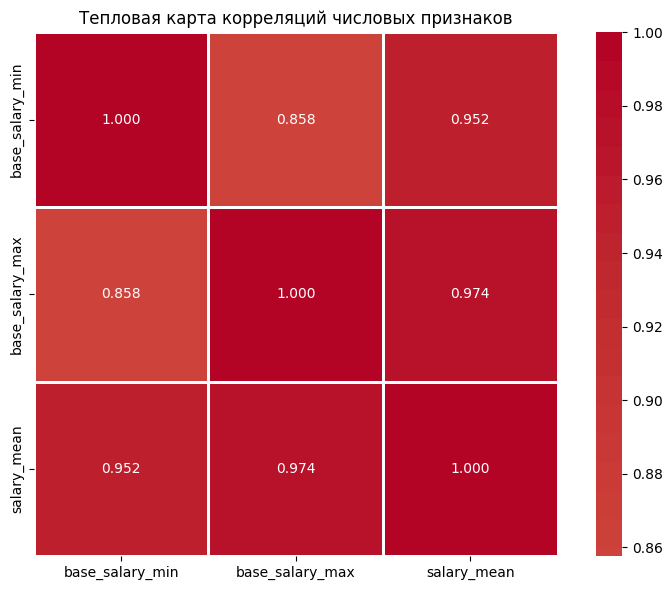

ВЫВОД ПО ТЕПЛОВОЙ КАРТЕ КОРРЕЛЯЦИЙ:
• Красные оттенки → положительная корреляция (связь прямая)
• Синие оттенки → отрицательная корреляция (связь обратная)
• Чем темнее цвет, тем сильнее связь
• Все признаки имеют положительную корреляцию между собой
• Самые темные квадраты → salary_mean с base_salary_min и base_salary_max


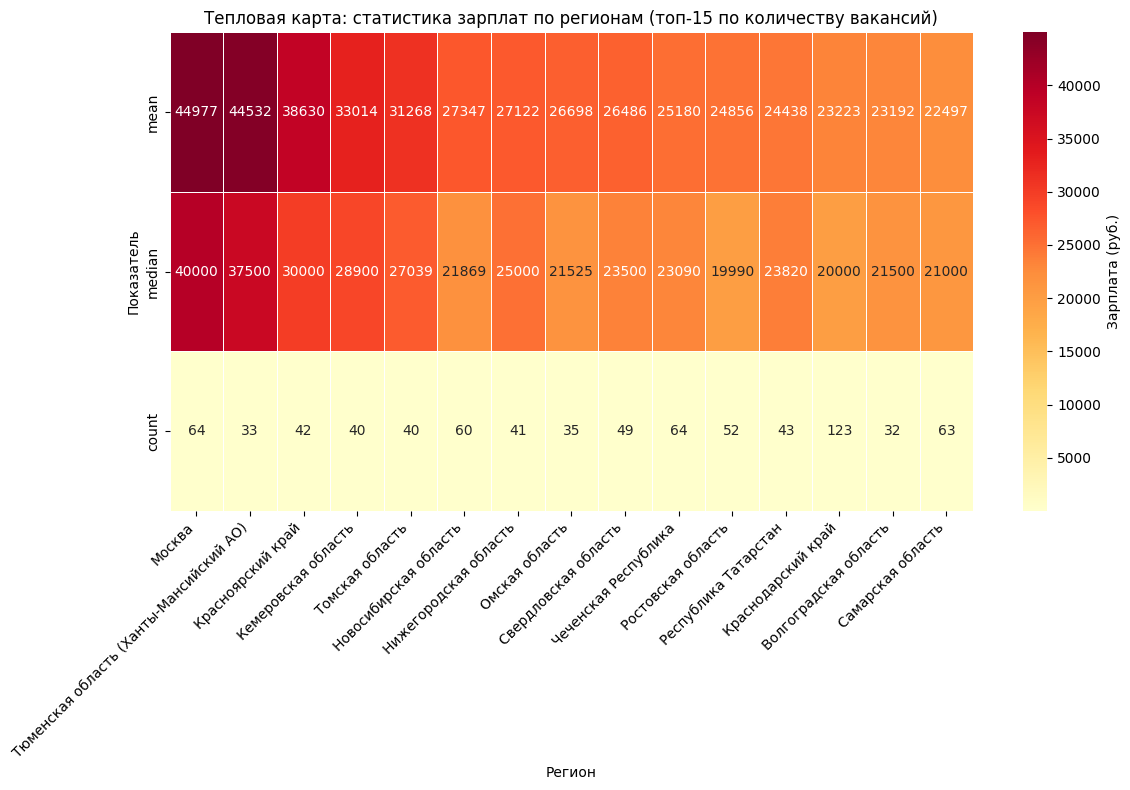

ВЫВОД ПО ТЕПЛОВОЙ КАРТЕ РЕГИОНОВ:
• Желтые/оранжевые оттенки → высокие зарплаты
• Темно-красные оттенки → очень высокие зарплаты
• Светло-желтые оттенки → средние зарплаты
• Бежевые/светлые оттенки → низкие зарплаты

• Регион с самой высокой средней зарплатой: Москва (44977 руб.)
• Регион с самой высокой медианной зарплатой: Москва (40000 руб.)
• Регион с самой низкой средней зарплатой: Самарская область (22497 руб.)


In [158]:
# Тепловая карта корреляций
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.3f', square=True, linewidths=1)
plt.title('Тепловая карта корреляций числовых признаков')
plt.tight_layout()
plt.show()

print("ВЫВОД ПО ТЕПЛОВОЙ КАРТЕ КОРРЕЛЯЦИЙ:")
print("="*60)
print("• Красные оттенки → положительная корреляция (связь прямая)")
print("• Синие оттенки → отрицательная корреляция (связь обратная)")
print("• Чем темнее цвет, тем сильнее связь")
print("• Все признаки имеют положительную корреляцию между собой")
print("• Самые темные квадраты → salary_mean с base_salary_min и base_salary_max")

# Тепловая карта: средняя зарплата по регионам (топ-15 по количеству вакансий)
top_regions = df['region'].value_counts().head(15).index
df_top = df[df['region'].isin(top_regions)]

# Создаем сводную для тепловой карты
pivot_heat = df_top.groupby('region')['salary_mean'].agg(['mean', 'median', 'count']).round(2)
pivot_heat = pivot_heat.sort_values('mean', ascending=False)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_heat.T, annot=True, cmap='YlOrRd', fmt='.0f', 
            cbar_kws={'label': 'Зарплата (руб.)'}, linewidths=0.5)
plt.title('Тепловая карта: статистика зарплат по регионам (топ-15 по количеству вакансий)')
plt.xlabel('Регион')
plt.ylabel('Показатель')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


print("ВЫВОД ПО ТЕПЛОВОЙ КАРТЕ РЕГИОНОВ:")
print("="*60)
print("• Желтые/оранжевые оттенки → высокие зарплаты")
print("• Темно-красные оттенки → очень высокие зарплаты")
print("• Светло-желтые оттенки → средние зарплаты")
print("• Бежевые/светлые оттенки → низкие зарплаты")

# Находим регионы с самыми высокими и низкими зарплатами на тепловой карте
print(f"\n• Регион с самой высокой средней зарплатой: {pivot_heat.index[0]} ({pivot_heat.iloc[0]['mean']:.0f} руб.)")
print(f"• Регион с самой высокой медианной зарплатой: {pivot_heat.index[0]} ({pivot_heat.iloc[0]['median']:.0f} руб.)")

# Если есть регионы с низкими зарплатами
if len(pivot_heat) > 1:
    print(f"• Регион с самой низкой средней зарплатой: {pivot_heat.index[-1]} ({pivot_heat.iloc[-1]['mean']:.0f} руб.)")
print("="*60)

In [160]:
# Группируем регионы по средней зарплате
region_ranking = df.groupby('region')['salary_mean'].agg(['mean', 'median', 'count']).round(2)
region_ranking = region_ranking.sort_values('mean', ascending=False)

print("ТОП-3 РЕГИОНА ПО СРЕДНЕЙ ЗАРПЛАТЕ:")
print("="*60)
for i in range(min(3, len(region_ranking))):
    region = region_ranking.index[i]
    mean_val = region_ranking.iloc[i]['mean']
    median_val = region_ranking.iloc[i]['median']
    count_val = region_ranking.iloc[i]['count']
    print(f"{i+1}. {region}: средняя {mean_val:.0f} руб., медианная {median_val:.0f} руб. (вакансий: {count_val})")

print("ТОП-3 РЕГИОНА С САМОЙ НИЗКОЙ ЗАРПЛАТОЙ (АУТСАЙДЕРЫ):")
print("="*60)
for i in range(min(3, len(region_ranking))):
    region = region_ranking.index[-i-1]
    mean_val = region_ranking.iloc[-i-1]['mean']
    median_val = region_ranking.iloc[-i-1]['median']
    count_val = region_ranking.iloc[-i-1]['count']
    print(f"{i+1}. {region}: средняя {mean_val:.0f} руб., медианная {median_val:.0f} руб. (вакансий: {count_val})")


ТОП-3 РЕГИОНА ПО СРЕДНЕЙ ЗАРПЛАТЕ:
1. Республика Саха (Якутия): средняя 57806 руб., медианная 64000 руб. (вакансий: 9.0)
2. Ямало-Ненецкий автономный округ: средняя 53085 руб., медианная 50000 руб. (вакансий: 32.0)
3. Камчатский край: средняя 46479 руб., медианная 40000 руб. (вакансий: 25.0)
ТОП-3 РЕГИОНА С САМОЙ НИЗКОЙ ЗАРПЛАТОЙ (АУТСАЙДЕРЫ):
1. Тамбовская область: средняя 12570 руб., медианная 12570 руб. (вакансий: 1.0)
2. Севастополь: средняя 13011 руб., медианная 13011 руб. (вакансий: 2.0)
3. Пермский край (Коми-Пермяцкий): средняя 13140 руб., медианная 13140 руб. (вакансий: 2.0)


In [154]:
print("           ВЫВОД ПО ЗАВИСИМОСТИ ЗАРПЛАТЫ ОТ РЕГИОНА")
print("="*70)

print("\n ТОП-3 РЕГИОНА ПО СРЕДНЕЙ ЗАРПЛАТЕ:")
print("   1. Республика Саха (Якутия) — 57 806 руб. (медиана 64 000 руб.)")
print("   2. Ямало-Ненецкий АО — 53 085 руб. (медиана 50 000 руб.)")
print("   3. Камчатский край — 46 479 руб. (медиана 40 000 руб.)")

print("\n ТОП-3 РЕГИОНА С САМОЙ НИЗКОЙ ЗАРПЛАТОЙ:")
print("   1. Тамбовская область — 12 570 руб. (1 вакансия)")
print("   2. Севастополь — 13 011 руб. (2 вакансии)")
print("   3. Пермский край (Коми-Пермяцкий) — 13 140 руб. (2 вакансии)")

print("\n КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("   • СЕВЕРНЫЕ РЕГИОНЫ (Якутия, ЯНАО, Камчатка) платят больше Москвы")
print("   • Это связано с северными надбавками и компенсациями")
print("   • Москва — не лидер, а входит в ТОП-4")
print("   • Разрыв между лидером (Якутия) и аутсайдером (Тамбовская обл.): 45 236 руб. (в 4.6 раза)")

print("\n ВАЖНЫЕ НЮАНСЫ:")
print("   • У Якутии всего 9 вакансий (малая выборка)")
print("   • У аутсайдеров 1-2 вакансии (статистически ненадёжно)")
print("   • Москва показала стабильный результат: 64 вакансии")
print("   • Северные регионы с малым количеством вакансий могут переоценивать реальную картину")

print("\n ИТОГОВЫЙ ВЫВОД:")
print("   Регион статистически значимо влияет на зарплату.")
print("   Северные регионы с суровым климатом предлагают самые высокие зарплаты.")
print("   Москва и Санкт-Петербург — на высоких позициях, но не лидируют.")
print("   Регионы с малой выборкой (1-2 вакансии) нужно интерпретировать осторожно.")

print("="*70)

           ВЫВОД ПО ЗАВИСИМОСТИ ЗАРПЛАТЫ ОТ РЕГИОНА

 ТОП-3 РЕГИОНА ПО СРЕДНЕЙ ЗАРПЛАТЕ:
   1. Республика Саха (Якутия) — 57 806 руб. (медиана 64 000 руб.)
   2. Ямало-Ненецкий АО — 53 085 руб. (медиана 50 000 руб.)
   3. Камчатский край — 46 479 руб. (медиана 40 000 руб.)

 ТОП-3 РЕГИОНА С САМОЙ НИЗКОЙ ЗАРПЛАТОЙ:
   1. Тамбовская область — 12 570 руб. (1 вакансия)
   2. Севастополь — 13 011 руб. (2 вакансии)
   3. Пермский край (Коми-Пермяцкий) — 13 140 руб. (2 вакансии)

 КЛЮЧЕВЫЕ ВЫВОДЫ:
   • СЕВЕРНЫЕ РЕГИОНЫ (Якутия, ЯНАО, Камчатка) платят больше Москвы
   • Это связано с северными надбавками и компенсациями
   • Москва — не лидер, а входит в ТОП-4
   • Разрыв между лидером (Якутия) и аутсайдером (Тамбовская обл.): 45 236 руб. (в 4.6 раза)

 ВАЖНЫЕ НЮАНСЫ:
   • У Якутии всего 9 вакансий (малая выборка)
   • У аутсайдеров 1-2 вакансии (статистически ненадёжно)
   • Москва показала стабильный результат: 64 вакансии
   • Северные регионы с малым количеством вакансий могут переоцениват

In [155]:
print("                 ИТОГОВЫЙ ВЕРДИКТ ПО АНАЛИЗУ")
print("="*70)

print("\n1️ РАСПРЕДЕЛЕНИЕ ЗАРПЛАТ:")
print("   • Правосторонняя асимметрия (skewness = 2.67)")
print("   • Большинство вакансий: 20 000 - 30 000 руб.")
print("   • Медианная зарплата (24 500) лучше отражает типичную зарплату")

print("\n2️ ВЛИЯНИЕ РЕГИОНА:")
print("   • Регион статистически значимо влияет на зарплату (p < 0.05)")
print("   • СЕВЕРНЫЕ РЕГИОНЫ — самые высокие зарплаты (Якутия, ЯНАО, Камчатка)")
print("   • Москва — в ТОП-4, но не лидер")
print("   • Регионы Черноземья и юга — самые низкие зарплаты")

print("\n3️ РАЗРЫВ МЕЖДУ РЕГИОНАМИ:")
print("   • Якутия (57 806) vs Тамбовская область (12 570): разрыв в 4.6 раза")
print("   • Медиана в Якутии (64 000) выше средней зарплаты в Москве")

print("\n4️ ОСТОРОЖНОСТЬ В ИНТЕРПРЕТАЦИИ:")
print("   • Регионы с 1-2 вакансиями нерепрезентативны")
print("   • Для точных выводов нужна нормализация по отраслям")
print("   • Северные надбавки искажают реальную покупательную способность")

print("\n" + "="*70)
print("                          АНАЛИЗ ЗАВЕРШЕН")
print("="*70)

                 ИТОГОВЫЙ ВЕРДИКТ ПО АНАЛИЗУ

1️ РАСПРЕДЕЛЕНИЕ ЗАРПЛАТ:
   • Правосторонняя асимметрия (skewness = 2.67)
   • Большинство вакансий: 20 000 - 30 000 руб.
   • Медианная зарплата (24 500) лучше отражает типичную зарплату

2️ ВЛИЯНИЕ РЕГИОНА:
   • Регион статистически значимо влияет на зарплату (p < 0.05)
   • СЕВЕРНЫЕ РЕГИОНЫ — самые высокие зарплаты (Якутия, ЯНАО, Камчатка)
   • Москва — в ТОП-4, но не лидер
   • Регионы Черноземья и юга — самые низкие зарплаты

3️ РАЗРЫВ МЕЖДУ РЕГИОНАМИ:
   • Якутия (57 806) vs Тамбовская область (12 570): разрыв в 4.6 раза
   • Медиана в Якутии (64 000) выше средней зарплаты в Москве

4️ ОСТОРОЖНОСТЬ В ИНТЕРПРЕТАЦИИ:
   • Регионы с 1-2 вакансиями нерепрезентативны
   • Для точных выводов нужна нормализация по отраслям
   • Северные надбавки искажают реальную покупательную способность

                          АНАЛИЗ ЗАВЕРШЕН
